In [18]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib


In [5]:
df = pd.read_csv('./dataset_eda/UNSW_NB15_training-set.csv')

X = df.drop(columns=['id','label','attack_cat'])
Y = df['label']

In [6]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

X_test, X_val, Y_test, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp)

In [7]:
transformer = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(), ['proto', 'service', 'state']),
    ],
    remainder='passthrough'
)

## BaseModel LogisticRegression

In [8]:
basepipe = Pipeline([
    ("transformer", transformer),
    ("classifier", LogisticRegression(max_iter=50000))])

In [9]:
basepipe.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](42,)","['dur','proto','service',...,'ct_src_ltm','ct_srv_dst','is_sm_ips_ports']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,42
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remainin

In [10]:
print("Training set evaluation:")
print("Accuracy:", basepipe.score(X_train, Y_train))
print("Validation set evaluation:")
print("Accuracy:", basepipe.score(X_test, Y_test))
print("Test set evaluation:")
print("Accuracy:", basepipe.score(X_test, Y_test))

Training set evaluation:
Accuracy: 0.7539664465193957
Validation set evaluation:
Accuracy: 0.7528240009716992
Test set evaluation:
Accuracy: 0.7528240009716992


Test accuracy: 75.2824%
Test classification report:
              precision    recall  f1-score   support

           0     0.6772    0.8600    0.7577      3700
           1     0.8534    0.6653    0.7477      4533

    accuracy                         0.7528      8233
   macro avg     0.7653    0.7627    0.7527      8233
weighted avg     0.7742    0.7528    0.7522      8233

Test confusion matrix: [[3182  518]
 [1517 3016]]
Validation accuracy: 74.8118%
Validation classification report:
              precision    recall  f1-score   support

           0     0.6727    0.8559    0.7533      3700
           1     0.8488    0.6601    0.7427      4534

    accuracy                         0.7481      8234
   macro avg     0.7608    0.7580    0.7480      8234
weighted avg     0.7697    0.7481    0.7475      8234

Validation confusion matrix: [[3167  533]
 [1541 2993]]


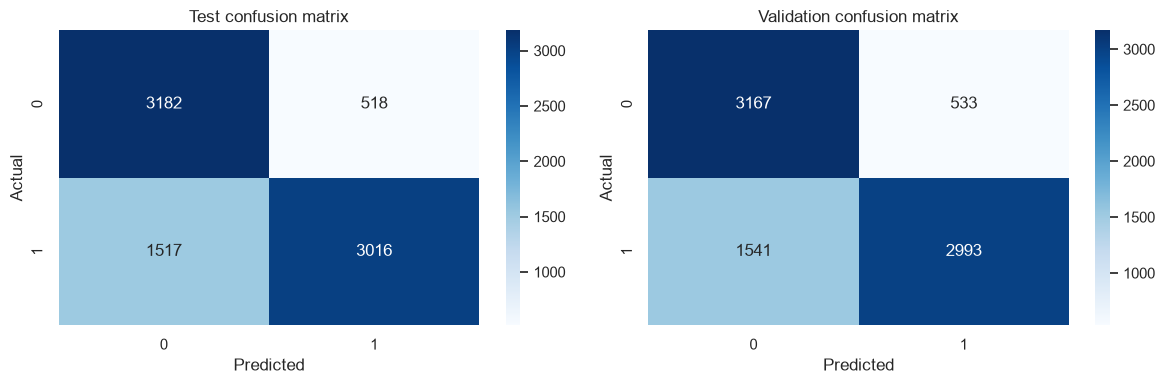

In [11]:
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Y_pred_test = basepipe.predict(X_test)
print(f"Test accuracy: {accuracy_score(Y_test, Y_pred_test):.4%}")
print("Test classification report:")
print(classification_report(Y_test, Y_pred_test, digits=4))
cm_test = confusion_matrix(Y_test, Y_pred_test)
print("Test confusion matrix:", cm_test)

Y_pred_val = basepipe.predict(X_val)
print(f"Validation accuracy: {accuracy_score(Y_val, Y_pred_val):.4%}")
print("Validation classification report:")
print(classification_report(Y_val, Y_pred_val, digits=4))
cm_val = confusion_matrix(Y_val, Y_pred_val)
print("Validation confusion matrix:", cm_val)

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_test, annot=True, fmt="d", ax=axes[0], cmap="Blues")
axes[0].set_title("Test confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
sns.heatmap(cm_val, annot=True, fmt="d", ax=axes[1], cmap="Blues")
axes[1].set_title("Validation confusion matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()


## Final Model

In [12]:
pipe = Pipeline([
    ("transformer", transformer),
    ("classifier", RandomForestClassifier(max_depth=10,n_estimators=350, random_state=42))])

In [13]:
pipe.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](42,)","['dur','proto','service',...,'ct_src_ltm','ct_srv_dst','is_sm_ips_ports']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,42
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remainin

In [14]:
print("Training set evaluation:")
print("Accuracy:", pipe.score(X_train, Y_train))
print("Validation set evaluation:")
print("Accuracy:", pipe.score(X_test, Y_test))
print("Test set evaluation:")
print("Accuracy:", pipe.score(X_test, Y_test))

Training set evaluation:
Accuracy: 0.9614666363015258
Validation set evaluation:
Accuracy: 0.9555447588971213
Test set evaluation:
Accuracy: 0.9555447588971213


Test accuracy: 95.5545%
Test classification report:
              precision    recall  f1-score   support

           0     0.9373    0.9657    0.9513      3700
           1     0.9713    0.9473    0.9591      4533

    accuracy                         0.9555      8233
   macro avg     0.9543    0.9565    0.9552      8233
weighted avg     0.9560    0.9555    0.9556      8233

Test confusion matrix: [[3573  127]
 [ 239 4294]]
Validation accuracy: 95.1299%
Validation classification report:
              precision    recall  f1-score   support

           0     0.9321    0.9616    0.9467      3700
           1     0.9679    0.9429    0.9552      4534

    accuracy                         0.9513      8234
   macro avg     0.9500    0.9522    0.9509      8234
weighted avg     0.9518    0.9513    0.9514      8234

Validation confusion matrix: [[3558  142]
 [ 259 4275]]


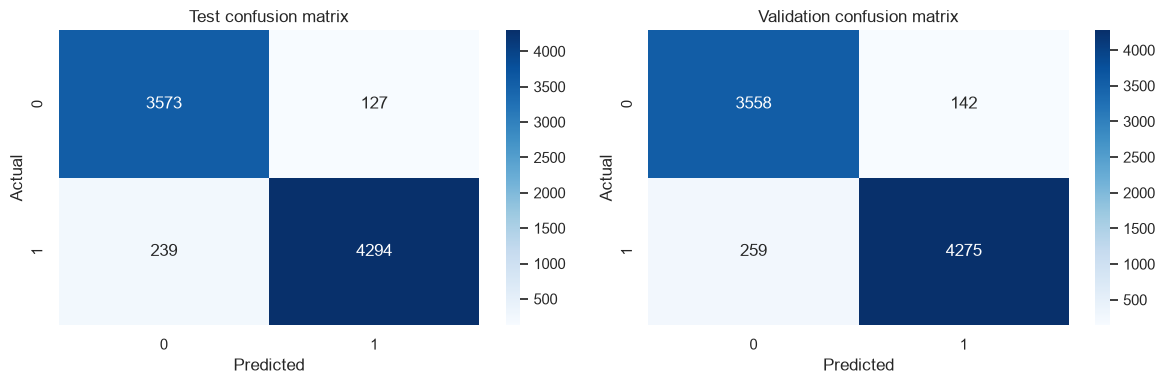

In [15]:
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Y_pred_test = pipe.predict(X_test)
print(f"Test accuracy: {accuracy_score(Y_test, Y_pred_test):.4%}")
print("Test classification report:")
print(classification_report(Y_test, Y_pred_test, digits=4))
cm_test = confusion_matrix(Y_test, Y_pred_test)
print("Test confusion matrix:", cm_test)

Y_pred_val = pipe.predict(X_val)
print(f"Validation accuracy: {accuracy_score(Y_val, Y_pred_val):.4%}")
print("Validation classification report:")
print(classification_report(Y_val, Y_pred_val, digits=4))
cm_val = confusion_matrix(Y_val, Y_pred_val)
print("Validation confusion matrix:", cm_val)

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_test, annot=True, fmt="d", ax=axes[0], cmap="Blues")
axes[0].set_title("Test confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
sns.heatmap(cm_val, annot=True, fmt="d", ax=axes[1], cmap="Blues")
axes[1].set_title("Validation confusion matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()


In [20]:
joblib.dump(pipe, './saved_models/rf_model.pkl')

['./saved_models/rf_model.pkl']

In [21]:
joblib.dump(basepipe, './saved_models/lr_model.pkl')

['./saved_models/lr_model.pkl']